# Load Data

In [82]:
from neural_lam import constants, utils, config

config_loader = config.Config.from_file("/mimer/NOBACKUP/groups/mlhighres/users/erifh/neural-lam/neural_lam/clim_config.yaml")

In [83]:
from neural_lam.netCDF_dataset import NetCDFDataset

dataset=NetCDFDataset(
            start_date=config_loader.dataset.train_start_date,
            end_date=config_loader.dataset.train_end_date,
            input_path=config_loader.dataset.input_path,
            input_files=config_loader.dataset.input_files,
            ground_truth_path=config_loader.dataset.ground_truth_path,
            ground_truth_files=config_loader.dataset.ground_truth_files,
            ground_truth_stats_path=config_loader.dataset.ground_truth_stats_path,
            levels=config_loader.dataset.levels,
            is_inference_dataset=False,
            normalize_ground_truth=config_loader.dataset.normalize_ground_truth,
            subset_ds=True,
            upscale_inputs=config_loader.dataset.upscale_inputs,
            static_fields_files=config_loader.dataset.static_fields_files,
            interpolation_mode=config_loader.dataset.interpolation_mode,
            provide_coordinates=config_loader.dataset.provide_coordinates,
            provide_day_of_year=config_loader.dataset.provide_day_of_year
        )

input_files: ['standardized.clt_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.hus_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.pr_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_mm_day_noleap.nc', 'standardized.psl_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.tas_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.ta_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.ua_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc', 'standardized.va_day_EC-Earth3-Veg_historical_r1i1p1f1_gr_1951-2014_noleap.nc']
Reading static fields from ['standardized.remapped.orog_EUR-12_EC-Earth3-Veg_historical_r1i1p1f1_HCLIMcom-SMHI_HCLIM43-ALADIN_v1-r1_fx.nc', 'scaled.remapped.sftlf_EUR-12_EC-Earth3-Veg_historical_r1i1p1f1_HCLIMcom-SMHI_HCLIM43-ALADIN_v1-r1_fx.nc']...
Providing ground truth coordinate grid...
Providing day of year encodings...


In [84]:
sample = dataset[0]
LQ = sample['LQ'][8]
HQ = sample['HQ'][1]
print("LQ shape:", LQ.shape)
print("HQ shape:", HQ.shape)

LQ shape: torch.Size([400, 550])
HQ shape: torch.Size([400, 550])


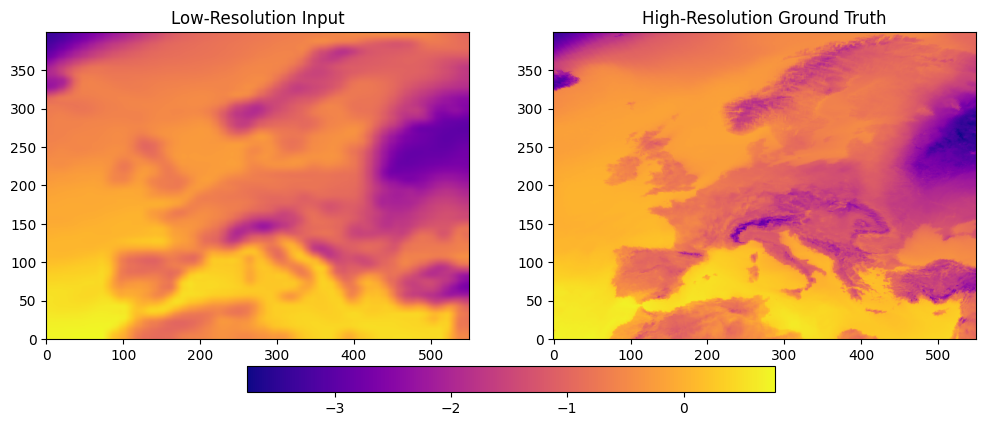

In [85]:
from matplotlib import pyplot as plt
import numpy as np

lq_arr = LQ.cpu().numpy()
hq_arr = HQ.cpu().numpy()
vmin = float(np.minimum(lq_arr.min(), hq_arr.min()))
vmax = float(np.maximum(lq_arr.max(), hq_arr.max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].set_title("Low-Resolution Input")
im = axes[0].imshow(lq_arr, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
axes[1].set_title("High-Resolution Ground Truth")
axes[1].imshow(hq_arr, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)

# make room for a single horizontal colorbar and draw it
fig.subplots_adjust(bottom=0.)
fig.colorbar(im, ax=axes.ravel().tolist(), orientation="horizontal", fraction=0.05, pad=0.05)

plt.show()

# Visualize Diffusion

In [92]:
import torch

num_steps = 4
sigma_max = 80
sigma_min = 0.03
sigma_max_train = 88
sigma_min_train = 0.02
rho = 7

t_steps = (sigma_max ** (1 / rho) + torch.arange(num_steps, dtype=torch.float32) / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
t_steps = torch.cat([torch.as_tensor(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0

t_steps_train = (sigma_max_train ** (1 / rho) + torch.arange(num_steps, dtype=torch.float32) / (num_steps - 1) * (sigma_min_train ** (1 / rho) - sigma_max_train ** (1 / rho))) ** rho
t_steps_train = torch.cat([torch.as_tensor(t_steps_train), torch.zeros_like(t_steps_train[:1])]) # t_N = 0

diffusion_steps = [HQ + t_step * torch.randn_like(HQ) for t_step in t_steps]

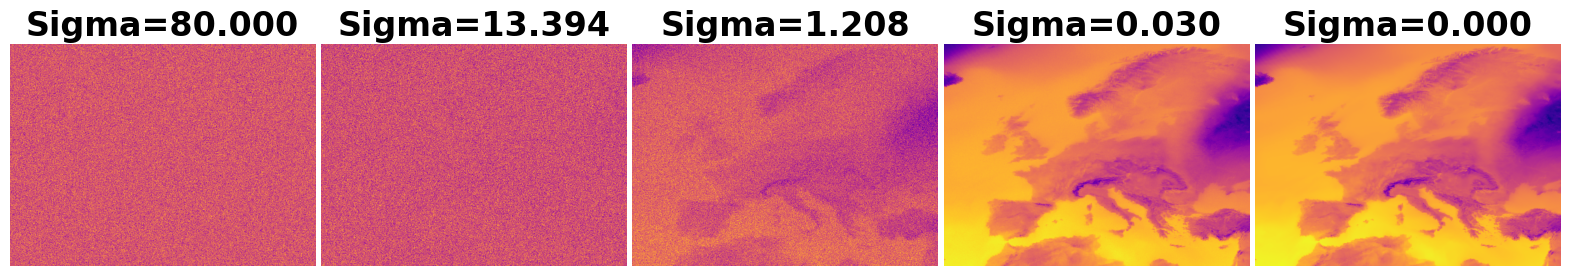

In [98]:
steps = list(diffusion_steps)  # list of tensors (same order as t_steps)
FONTSIZE=24
# ensure HQ is the last image
if not torch.allclose(steps[-1], HQ):
    steps.append(HQ)

def to2d(x):
    a = x.cpu().numpy()
    # handle possible channel dimension: prefer a 2D image
    if a.ndim == 3:
        # common layout (C, H, W) or (H, W, C)
        if a.shape[0] <= 4:  # assume (C, H, W)
            return a[0]
        elif a.shape[-1] <= 4:  # assume (H, W, C)
            return a[..., 0]
    return a.squeeze()

imgs = [to2d(s) for s in steps]

# vmin = float(min(img.min() for img in imgs))
# vmax = float(max(img.max() for img in imgs))

n = len(imgs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
axes = axes[0]

im = None
for i, img in enumerate(imgs):
    ax = axes[i]
    t_title = None
    if i < len(t_steps):
        t_val = float(t_steps[i].item())
        t_title = f"Sigma={t_val:.3f}"
    else:
        t_title = "HQ (t=0)"
    ax.set_title(t_title, fontsize=FONTSIZE, fontweight="bold")
    im = ax.imshow(img, cmap="plasma", origin="lower") #, vmin=vmin, vmax=vmax)
    ax.axis("off")

# shared horizontal colorbar
fig.subplots_adjust(bottom=0.15, wspace=0.02)
# fig.colorbar(im, ax=axes.tolist(), orientation="horizontal", fraction=0.05, pad=0.06)

plt.show()

In [99]:
import os
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/diffusion.pdf", bbox_inches="tight", dpi=300)

# Visualize Stochastic Interpolants

In [100]:
from neural_lam.models.stochastic_interpolants import Interpolant

states_zt = []
states_target = []

timesteps = torch.linspace(0, 1, 100)
dt = timesteps[1] - timesteps[0]

I = Interpolant(sigma_coef=1, beta_fn='t^2')
x = LQ
for t in timesteps:

    t = torch.tensor([t])
    # Prepare batch
    D = {'z0': LQ, 'z1': HQ, 'label': None, 'N': LQ.shape[0]}   

    # Get random batch of times
    D['t'] = t

    # Conditioning on LQ
    D['cond'] = LQ

    # Interpolant noise
    D['noise'] = torch.rand_like(LQ, device=LQ.device)

    # Get alpha, beta, etc
    D = I.interpolant_coefs(D)

    # zt
    zt = I.compute_zt(D).squeeze()
    states_zt.append(zt)

    # Target
    x = x + I.compute_target(D).squeeze() * dt
    states_target.append(x)

states_zt = np.array(states_zt)
states_target = np.array(states_target)

print(states_zt.shape)

(100, 400, 550)


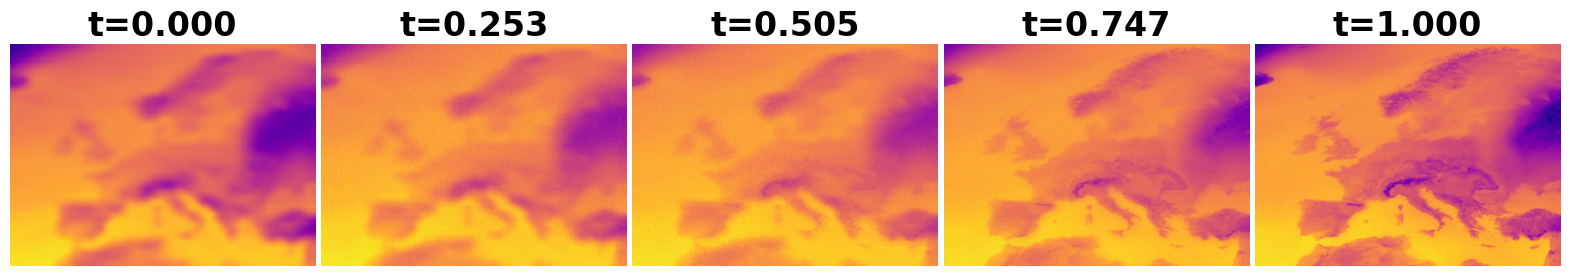

In [101]:
states = states_zt  # numpy array shape (100, H, W)
num_total = states.shape[0]

# compute indices that always include first and last and are as evenly spaced as possible
inds = np.linspace(0, num_total - 1, num_steps+1)
inds = np.rint(inds).astype(int)
inds[0] = 0
inds[-1] = num_total - 1
inds = np.unique(inds)  # ensure monotonic unique indices

imgs = [states[i] for i in inds]

# get t values for titles if timesteps available
if 'timesteps' in globals() or 'timesteps' in locals():
    t_arr = (
        timesteps.cpu().numpy()
        if torch.is_tensor(timesteps)
        else np.asarray(timesteps)
    )
else:
    t_arr = None

vmin = float(min(img.min() for img in imgs))
vmax = float(max(img.max() for img in imgs))

n = len(imgs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
axes = axes[0]

for ax, idx, img in zip(axes, inds, imgs):
    title = f"t={float(t_arr[idx]):.3f}" if t_arr is not None else f"idx={idx}"
    ax.set_title(title, fontsize=FONTSIZE, fontweight="bold")
    ax.imshow(img, cmap="plasma", origin="lower", vmin=vmin, vmax=vmax)
    ax.axis("off")

fig.subplots_adjust(bottom=0.15, wspace=0.02)
# fig.colorbar(axes[-1].images[0], ax=axes.tolist(), orientation="horizontal", fraction=0.05, pad=0.06)
plt.show()

In [102]:
import os
os.makedirs("plots", exist_ok=True)
fig.savefig("plots/SI.pdf", bbox_inches="tight", dpi=300)